# Clustering wine - A larger example

Here we will use a [dataset on Italian wine](https://archive.ics.uci.edu/dataset/109/wine). The actual data is in the file wine.data, and a description of the data can be found in wine.names.

First is the class of the wine and the follows the data, which are (taken from wines.names):<br>
1) Alcohol
2) Malic acid
3) Ash
4) Alcalinity of ash
5) Magnesium
6) Total phenols
7) Flavanoids
8) Nonflavanoid phenols
9) Proanthocyanins
10) Color intensity
11) Hue
12) OD280/OD315 of diluted wines
13) Proline 
        
The data is clearly a simple CSV file, thus we start by reading the data.

---

* Author: Troels C. Petersen (NBI) & Brian Vinter (formerly NBI, now AU)
* Email:  petersen@nbi.dk
* Date:   20th of April 2026

In [9]:
import csv
import numpy

with open('data_Wine.csv') as input_file:
    raw_data = numpy.array([row for row in csv.reader(input_file)]).astype(float)

labels = raw_data[:, 0 ]
data   = raw_data[:, 1:]

This time the data are not in the simple [0:1] range - so we normalize each column.

In [2]:
_, num_c = data.shape
for i in range(num_c):
    data[:, i] = data[:, i] / numpy.max(data[:, i])

We know that there are 13 columns in data, but at this point we may as well make our distance meassure indepedent of dimensions.

In [3]:
def all_distances(point, db):
    result = []
    for entry in db:
        distance = 0.0
        for dim in zip(point, entry):
                distance += (dim[0] - dim[1])**2
        result.append(numpy.sqrt(distance))
    return numpy.array(result)

# Clustering:

Your challenge is to see, if you can cluster the wine data using the various algorithms. Check (using the labels) how well you/the algorithms do.

In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn import datasets
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split, cross_val_score

import matplotlib.pyplot as plt
pd.set_option('display.max_columns', None)

In [10]:
#Let's import the data from sklearn
from sklearn.datasets import load_wine
wine=load_wine()

#Conver to pandas dataframe
data=pd.DataFrame(data=np.c_[wine['data'],wine['target']],columns=wine['feature_names']+['target'])

#Check data with info function
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  targe

In [6]:
#Let's import the data from sklearn
from sklearn.datasets import load_wine
wine=load_wine()

#Conver to pandas dataframe
data=pd.DataFrame(data=np.c_[wine['data'],wine['target']],columns=wine['feature_names']+['target'])

#Check data with info function
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  targe

In [11]:
(data.isnull() | data.empty | data.isna()).sum()

alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
target                          0
dtype: int64

<Axes: xlabel='target'>

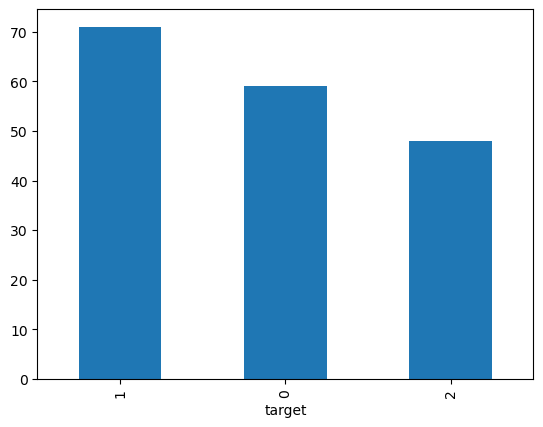

In [13]:
#Let's see the frequency of the variable target.
#Convert variable to categorical.
data.target=data.target.astype('int64').astype('category')

#Frequency.
freq=data['target'].value_counts()

freq.plot(kind='bar')

In [16]:
#Let's show a summary of teh dataset where we can see 
# the basic statistic data.
data.describe()
data


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0,2
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0,2
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0,2
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0,2


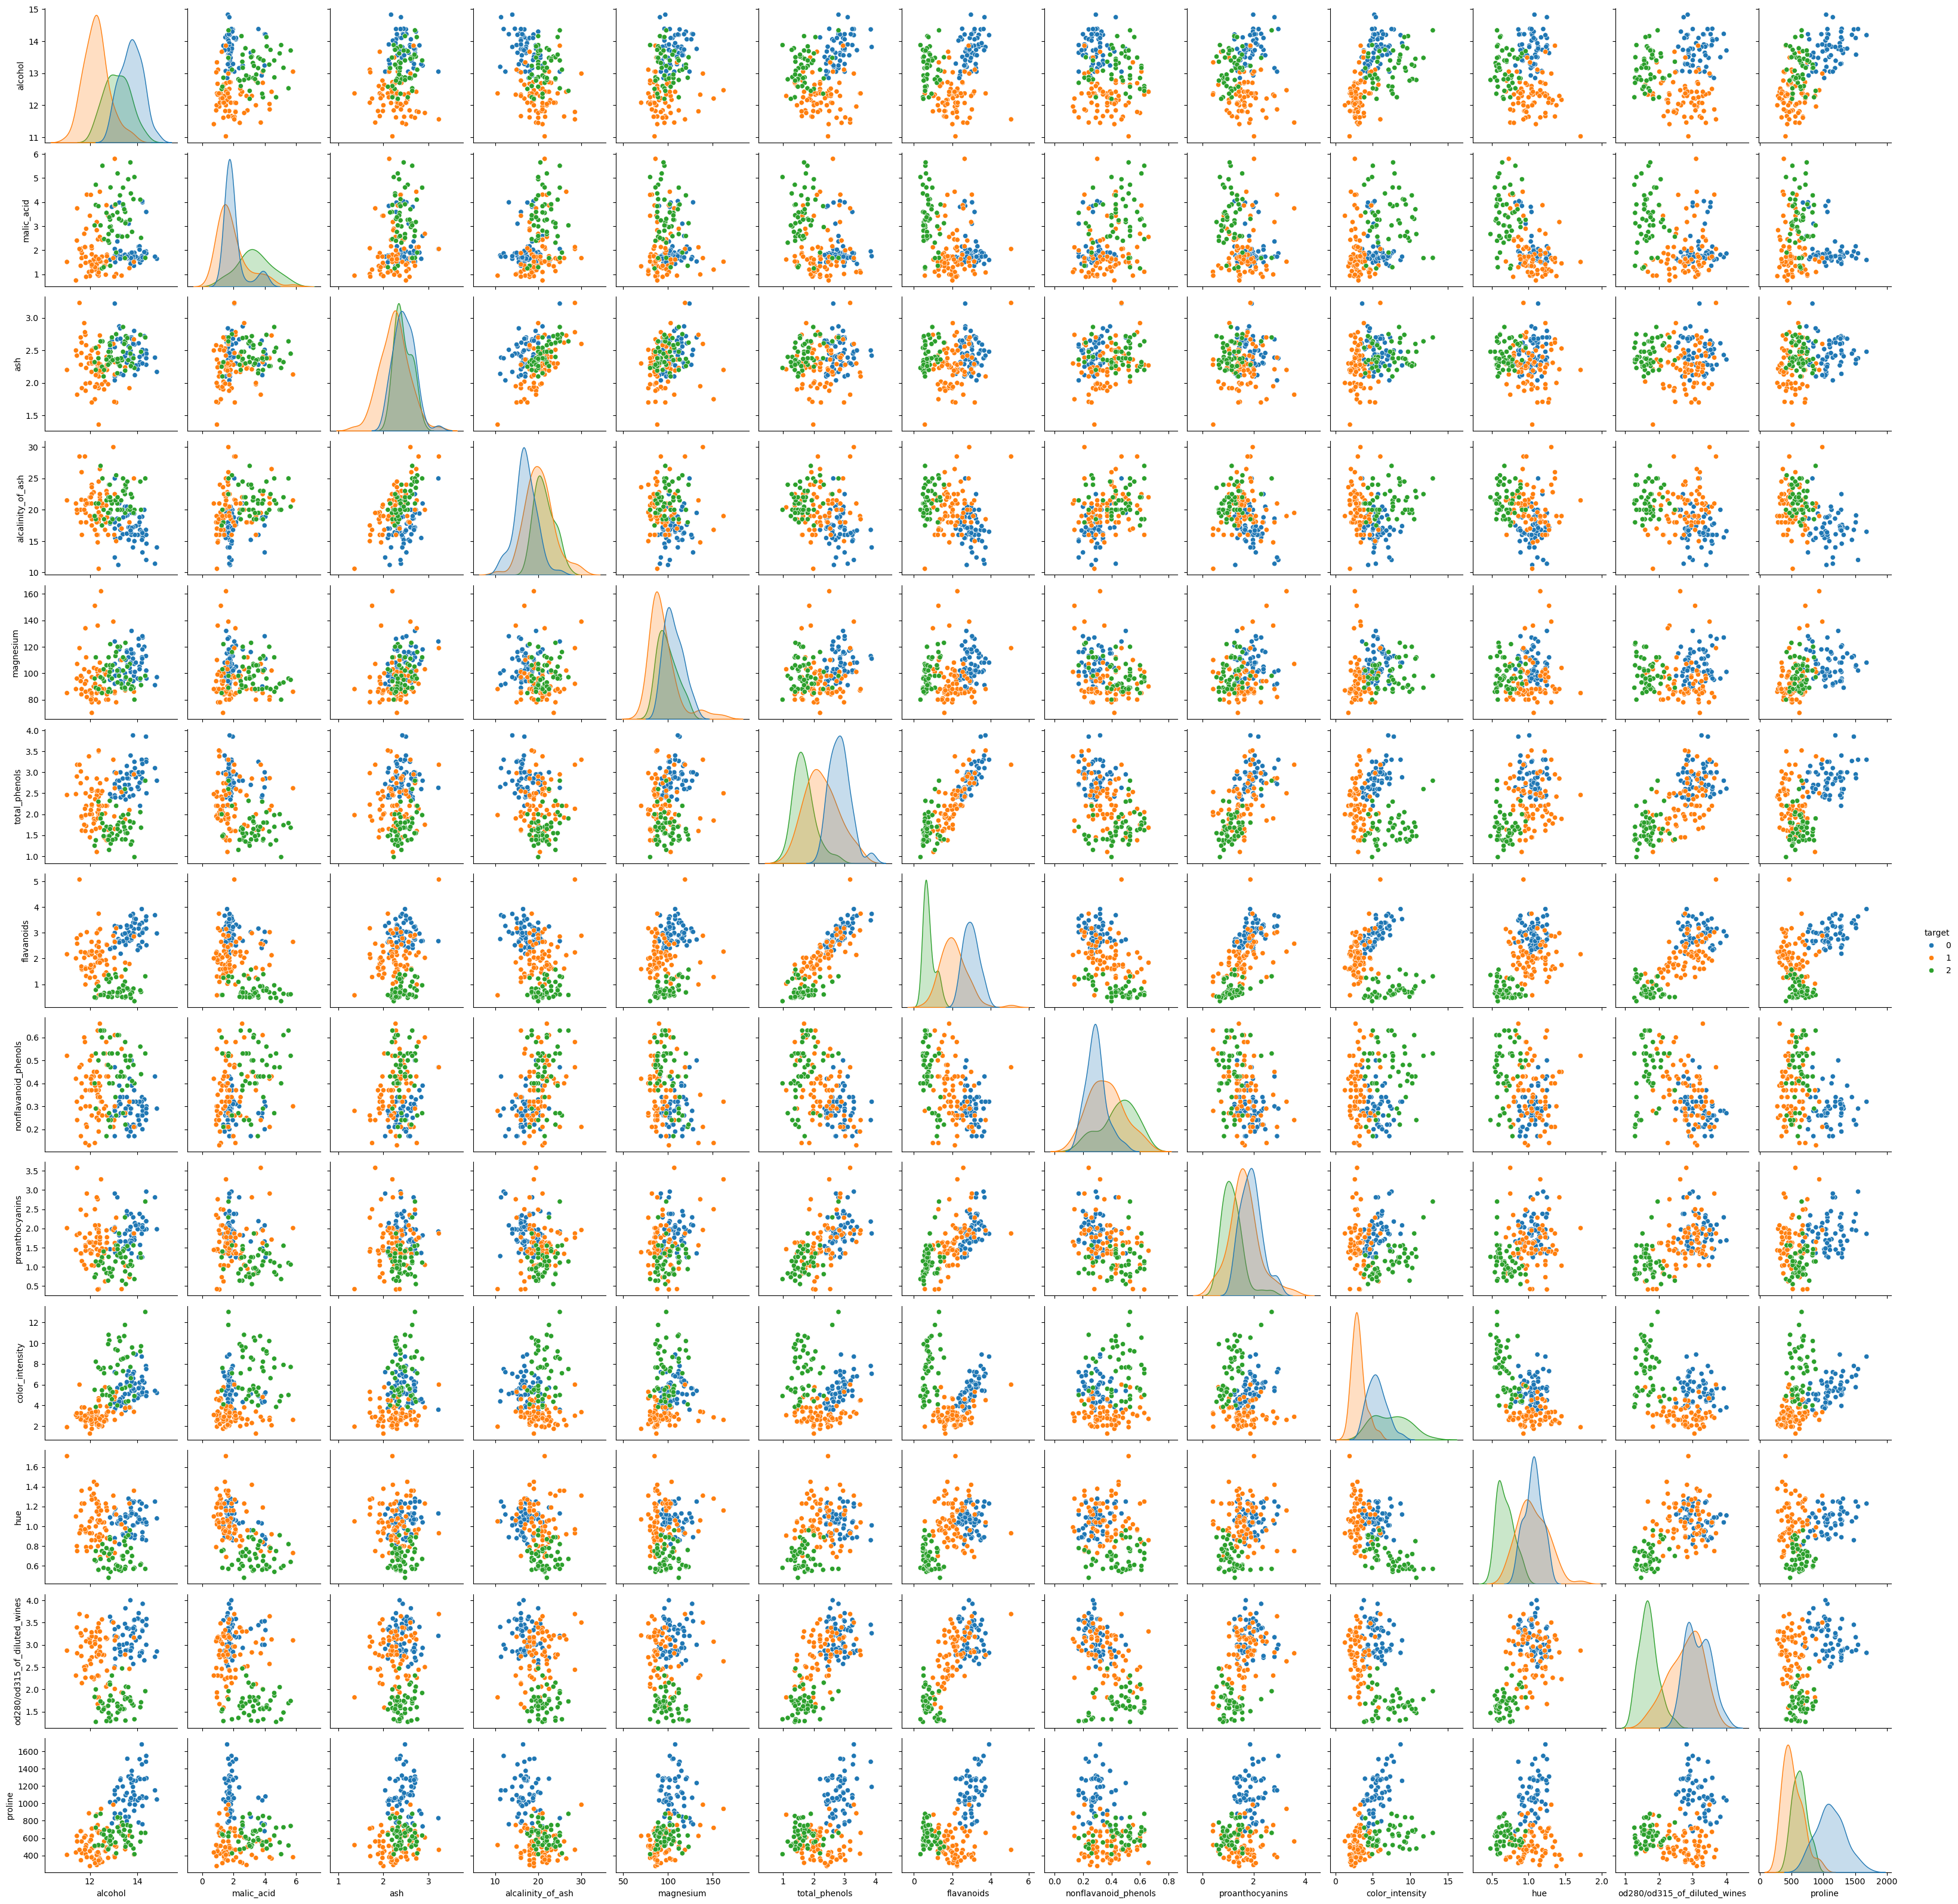

In [15]:
sns.pairplot(data,hue='target')

In [17]:
from sklearn.preprocessing import StandardScaler

X = data.drop('target', axis=1)  # features only

scaler = StandardScaler() # Transforms to mean 0 and variance 1
X_scaled = scaler.fit_transform(X)

In [18]:
from sklearn.cluster import MiniBatchKMeans

kmeans = MiniBatchKMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(X_scaled)

In [19]:
pd.crosstab(labels, wine['target'])

col_0,0,1,2
row_0,,,
0,0,21,0
1,59,36,0
2,0,14,48


col_0 is the target and row_0 is the clustering we did

In [20]:
from sklearn.metrics import adjusted_rand_score

ari = adjusted_rand_score(wine['target'], labels)
print(ari)

0.41624940085648326


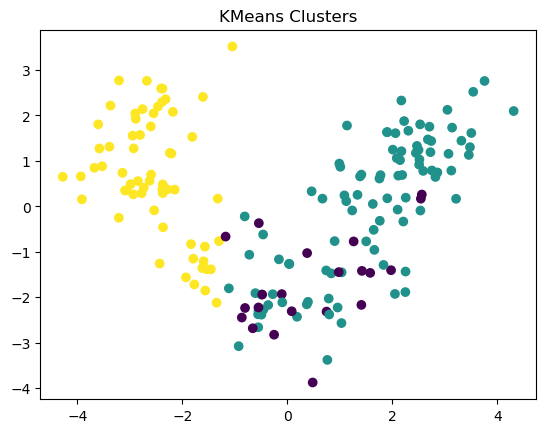

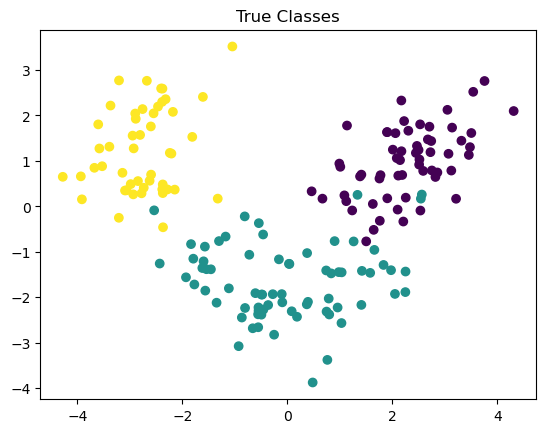

In [21]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels)
plt.title("KMeans Clusters")
plt.show()

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=wine['target'])
plt.title("True Classes")
plt.show()

In [23]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

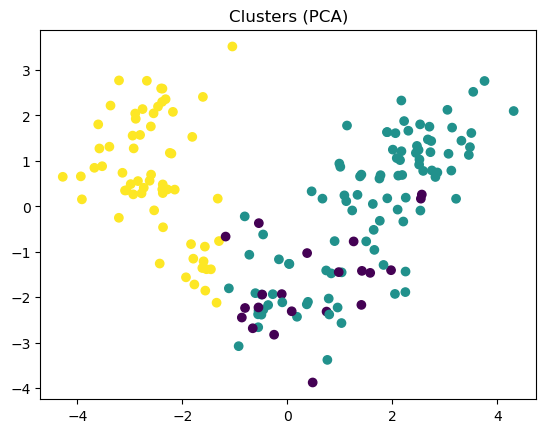

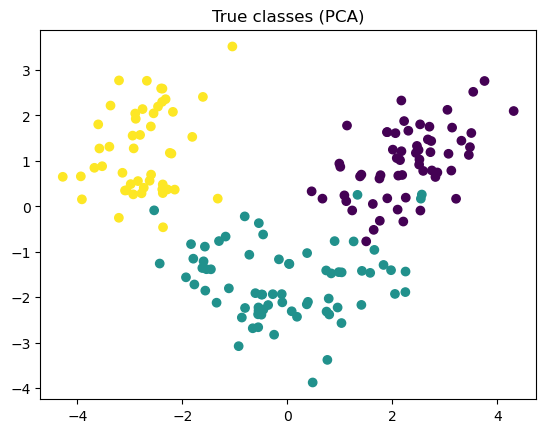

In [24]:
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels)
plt.title("Clusters (PCA)")
plt.show()

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=wine['target'])
plt.title("True classes (PCA)")
plt.show()

In [34]:
from sklearn.cluster import DBSCAN

db = DBSCAN(eps=2, min_samples=5)
labels_db = db.fit_predict(X_scaled)

pd.crosstab(labels_db, wine['target'])

col_0,0,1,2
row_0,,,
-1,12,44,29
0,47,19,0
1,0,8,0
2,0,0,5
3,0,0,5
4,0,0,9


In [35]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=3, random_state=42)
labels_gmm = gmm.fit_predict(X_scaled)

In [36]:
from sklearn.metrics import adjusted_rand_score

print("KMeans:", adjusted_rand_score(wine['target'], labels))
print("DBSCAN:", adjusted_rand_score(wine['target'], labels_db))
print("GMM:", adjusted_rand_score(wine['target'], labels_gmm))

KMeans: 0.41624940085648326
DBSCAN: 0.22049122985497493
GMM: 0.8974949815093207


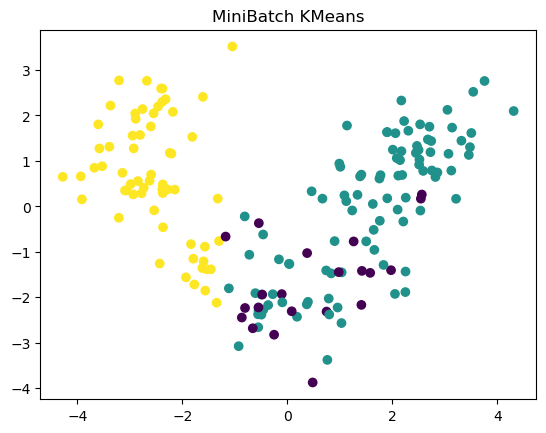

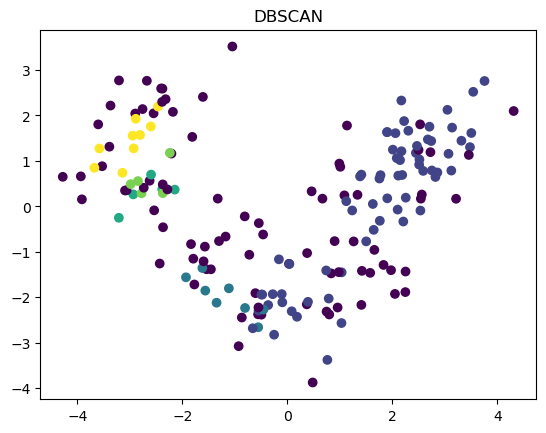

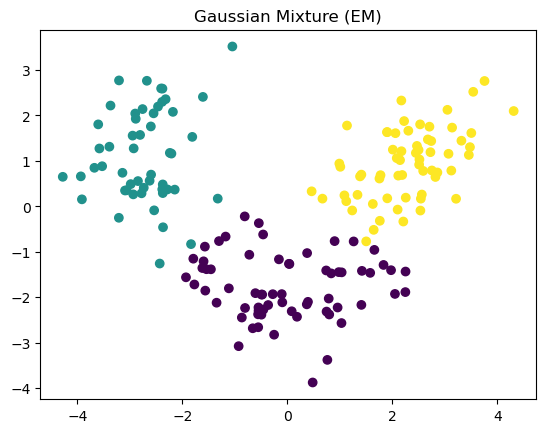

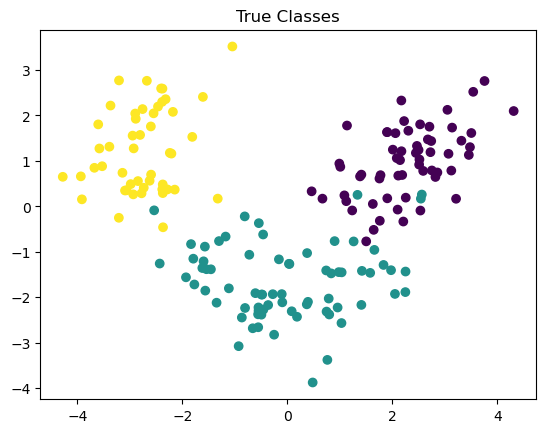

In [37]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels)
plt.title("MiniBatch KMeans")
plt.show()

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_db)
plt.title("DBSCAN")
plt.show()

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_gmm)
plt.title("Gaussian Mixture (EM)")
plt.show()

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=wine['target'])
plt.title("True Classes")
plt.show()

# Questions:

1. Take a close look at the original input data, and consider to what degree the variables are normalized.
2. Why do you need to normalize the data? And can you think of other ways to do so, than the one given?
3. Try to run a clustering algorithm, e.g. (MiniBatch) k-Means, on the data. Does it give anything sensible?
4. Try different values of k. Which value(s) seems like a fitting number of clusters?
5. Try several other clustering algorithms, and think about (and discuss) the differences between the results.
6. In order to visualize the result, try to reduce the number of dimensions to two (e.g. using PCA). Example code for this can be found in the file "Clustering_WineData_PCA.ipynb".

# Learning points:

1. Unsupervised learning is hard, as it is not easy to know, if the method worked and the result is good.
2. Data needs to be normalized for the metric to work.
3. It is not always clear which algorithm will work best. Possibly consult SciKit-Learn plot.
4. Clustering and dimensionality reduction often go hand in hand in order for you to visually inspect the results.

# Bonus Problem: k-Nearest-Neighbor (i.e. classification):

This part is not clustering, but classification based on the k nearest neighbors. We can (re)use the simple election mechanism.

In [5]:
import collections
def classify(point, k=5):
    distances = all_distances(point, data)
    votes = []
    for _ in range(k):
        winner = numpy.argmin(distances)
        votes.append(labels[winner])
        distances[winner] = 1000
    return collections.Counter(votes).most_common(1)[0][0]
    

Now we can test the result against the database itself.

In [6]:
score = 0
for point in raw_data:
    if point[0] == classify(point[1:], 6):
        score += 1
print('Matched', score, 'of', len(raw_data))

Matched 176 of 178


The result is quite satisfactory. However, since we are matching against the database itself, the tested point is itself in the test set, which is an unfair advantage compared to a real world scenario. Eliminating this bias is left as an exercise, it is quite simple though.

You should play around with values of k as well, to tell the best number of neighbors to match against.